<a href="https://colab.research.google.com/github/Shah-Shawon/Deep-Learing-Assignments/blob/main/DL_Assignment_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Denoising Autoencoder (DAE) on CIFAR-10 using TensorFlow/Keras

**Assignment Requirements Covered:**
- Design, train, and evaluate a Denoising Autoencoder to reconstruct clean images from corrupted inputs using **Gaussian** and **Salt-and-Pepper** noise.
- Analyze the **effect of noise levels** (0.05, 0.1, 0.2) on reconstruction quality using **CIFAR-10**.
- Examine the impact of **encoder architecture choices** and **different upsampling techniques** (Transposed Convolution vs Upsampling).
- Evaluate the model using **reconstruction loss (MSE)** and visualize denoised outputs vs original images.
- Propose methods to address the challenge of **limited annotated ground truth data**.

This notebook implements **exactly** what the assignment asks with proper documentation. No extra code added.

🔧 1. Setup & Imports

In [2]:
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, losses
import matplotlib.pyplot as plt
import numpy as np

# For reproducibility
tf.random.set_seed(42)
np.random.seed(42)

print("TensorFlow version:", tf.__version__)
print("Using GPU:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.20.0
Using GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 1. Adding Different Types of Noise
We implement Gaussian noise and Salt-and-Pepper noise as required by the assignment.
We will analyze different noise levels (0.05, 0.1, 0.2) to study their effect on reconstruction quality.

Noise Functions (Code)

In [3]:
def add_gaussian_noise(images, noise_level=0.1):
    """Add Gaussian noise"""
    noise = tf.random.normal(shape=tf.shape(images), mean=0.0, stddev=noise_level)
    noisy_images = images + noise
    return tf.clip_by_value(noisy_images, 0.0, 1.0)

def add_salt_pepper_noise(images, noise_level=0.1):
    """Add Salt-and-Pepper noise"""
    noisy_images = tf.identity(images)
    salt_pepper = tf.random.uniform(shape=tf.shape(images))
    noisy_images = tf.where(salt_pepper < noise_level/2, 0.0, noisy_images)
    noisy_images = tf.where(salt_pepper > 1 - noise_level/2, 1.0, noisy_images)
    return noisy_images

## 2. DAE Model Architectures
We implement two variants to examine the impact of upsampling techniques and encoder choices:
1. **TransposedConvDAE** — Uses Conv2DTranspose (transposed convolution upsampling)
2. **UpsamplingDAE** — Uses UpSampling2D + Conv2D (alternative to max unpooling)

Both share similar encoder (MaxPooling) but differ in decoder upsampling method.

Model Definitions (Code)

In [4]:
def build_transposed_dae():
    """DAE with Transposed Convolution upsampling"""
    inputs = layers.Input(shape=(32, 32, 3))

    # Encoder
    x = layers.Conv2D(64, (3, 3), padding='same', activation='relu')(inputs)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Conv2D(128, (3, 3), padding='same', activation='relu')(x)
    encoded = layers.MaxPooling2D((2, 2))(x)

    # Decoder with Transposed Convolution
    x = layers.Conv2DTranspose(64, (2, 2), strides=(2, 2), activation='relu')(encoded)
    x = layers.Conv2DTranspose(3, (2, 2), strides=(2, 2), activation='sigmoid')(x)

    model = models.Model(inputs, x, name="TransposedConvDAE")
    return model


def build_upsampling_dae():
    """DAE with UpSampling (proxy for Max Unpooling comparison)"""
    inputs = layers.Input(shape=(32, 32, 3))

    # Encoder (same as above)
    x = layers.Conv2D(64, (3, 3), padding='same', activation='relu')(inputs)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Conv2D(128, (3, 3), padding='same', activation='relu')(x)
    encoded = layers.MaxPooling2D((2, 2))(x)

    # Decoder with UpSampling2D
    x = layers.UpSampling2D((2, 2))(encoded)
    x = layers.Conv2D(64, (3, 3), padding='same', activation='relu')(x)
    x = layers.UpSampling2D((2, 2))(x)
    decoded = layers.Conv2D(3, (3, 3), padding='same', activation='sigmoid')(x)

    model = models.Model(inputs, decoded, name="UpsamplingDAE")
    return model

## 3. Loading CIFAR-10 Dataset
We use CIFAR-10 as specified in the assignment.

 Dataset Loading (Code)

### Accessing CIFAR-10 from Google Drive

Since direct download of CIFAR-10 has been problematic, we'll load it from a manually uploaded file on Google Drive. First, mount your Google Drive.

In [11]:
from google.colab import drive
drive.mount('/content/drive')
print("Google Drive mounted.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Google Drive mounted.


Now, let's extract the `cifar-10-python.tar.gz` file from your Google Drive to the local Colab environment. **Remember to update `drive_archive_path` with the correct path to your file in Google Drive.**

In [12]:
import tarfile
import os

# !!! IMPORTANT: Update this path to where you saved cifar-10-python.tar.gz in your Google Drive !!!
drive_archive_path = '/content/drive/MyDrive/cifar-10-python.tar.gz'
local_data_root = './data'

if not os.path.exists(local_data_root):
    os.makedirs(local_data_root)

# Copy the file from Drive to local Colab storage if it's not already there
local_archive_path = os.path.join(local_data_root, 'cifar-10-python.tar.gz')
if not os.path.exists(local_archive_path):
    if os.path.exists(drive_archive_path):
        print(f"Copying {drive_archive_path} to {local_archive_path}...")
        !cp "{drive_archive_path}" "{local_archive_path}"
        print("Copy complete.")
    else:
        print(f"Error: CIFAR-10 archive not found in Google Drive at '{drive_archive_path}'. Please check the path and ensure the file is there.")

if os.path.exists(local_archive_path):
    print(f"Extracting {local_archive_path}...")
    with tarfile.open(local_archive_path, "r:gz") as tar:
        tar.extractall(path=local_data_root)
    print("Extraction complete.")
else:
    print("Cannot extract: Local archive file not found.")

# Verify that the extracted folder exists
expected_folder = os.path.join(local_data_root, 'cifar-10-batches-py')
if os.path.exists(expected_folder):
    print(f"Verified: '{expected_folder}' exists. You can now load CIFAR-10.")
else:
    print(f"Warning: '{expected_folder}' does not exist after extraction. Check your Google Drive path and ensure the file was correctly copied and extracted.")

Extracting ./data/cifar-10-python.tar.gz...


/tmp/ipykernel_25498/1350674036.py:24: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(path=local_data_root)


Extraction complete.
Verified: './data/cifar-10-batches-py' exists. You can now load CIFAR-10.


In [14]:
import numpy as np
import pickle
import os

def load_cifar_batch(file_path):
    with open(file_path, 'rb') as f:
        datadict = pickle.load(f, encoding='bytes')
        X = datadict[b'data']
        Y = datadict[b'labels']
        # Reshape to NWHC for TensorFlow/Keras
        X = X.reshape(10000, 3, 32, 32).transpose(0, 2, 3, 1)
        Y = np.array(Y)
        return X, Y

def load_cifar10_locally(path='./data/cifar-10-batches-py'):
    xs = []
    ys = []
    for i in range(1, 6):
        filepath = os.path.join(path, f'data_batch_{i}')
        X, Y = load_cifar_batch(filepath)
        xs.append(X)
        ys.append(Y)
    x_train = np.concatenate(xs)
    y_train = np.concatenate(ys)

    filepath = os.path.join(path, 'test_batch')
    x_test, y_test = load_cifar_batch(filepath)

    return (x_train, y_train), (x_test, y_test)

# Load data from the local extracted files
(x_train, _), (x_test, _) = load_cifar10_locally()

x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

print("CIFAR-10 dataset loaded successfully from local files.")
print("Train shape:", x_train.shape, "Test shape:", x_test.shape)


CIFAR-10 dataset loaded successfully from local files.
Train shape: (50000, 32, 32, 3) Test shape: (10000, 32, 32, 3)


## 4. Training and Evaluation Functions
We use GradientTape for training so we can inject different noise types and levels per batch.
Models are evaluated using MSE reconstruction loss. Visualization shows Original | Noisy | Denoised.

In [21]:
def train_model(model, noise_type='gaussian', noise_level=0.1, epochs=6, batch_size=128):
    optimizer = optimizers.Adam(learning_rate=0.001)
    mse_loss = losses.MeanSquaredError()
    losses_history = []

    for epoch in range(epochs):
        epoch_loss = 0.0
        num_batches = len(x_train) // batch_size

        for i in range(num_batches):
            batch = x_train[i*batch_size:(i+1)*batch_size]

            if noise_type == 'gaussian':
                noisy_batch = add_gaussian_noise(batch, noise_level)
            else:
                noisy_batch = add_salt_pepper_noise(batch, noise_level)

            with tf.GradientTape() as tape:
                reconstructed = model(noisy_batch, training=True)
                loss = mse_loss(batch, reconstructed)

            grads = tape.gradient(loss, model.trainable_variables)
            optimizer.apply_gradients(zip(grads, model.trainable_variables))
            epoch_loss += loss.numpy()

        avg_loss = epoch_loss / num_batches
        losses_history.append(avg_loss)
        print(f'Epoch [{epoch+1}/{epochs}] | Noise: {noise_type} (level={noise_level}) | MSE Loss: {avg_loss:.6f}')
    return losses_history


def evaluate_and_visualize(model, noise_type='gaussian', noise_level=0.1, title=""):
    # Take first 6 test images
    test_images = x_test[:6]

    if noise_type == 'gaussian':
        noisy_images = add_gaussian_noise(test_images, noise_level)
    else:
        noisy_images = add_salt_pepper_noise(test_images, noise_level)

    reconstructed = model(noisy_images, training=False)
    # Fix: Directly calculate MSE using TensorFlow operations
    mse = tf.reduce_mean(tf.square(test_images - reconstructed)).numpy()

    print(f"\n{title} - Reconstruction MSE: {mse:.6f}")

    # Visualization: Original | Noisy | Denoised
    fig, axes = plt.subplots(3, 6, figsize=(15, 7))
    fig.suptitle(f"{title}\nNoise Type: {noise_type} | Noise Level: {noise_level} | MSE: {mse:.5f}", fontsize=14)

    for i in range(6):
        axes[0, i].imshow(test_images[i])
        axes[0, i].axis('off')
        axes[1, i].imshow(noisy_images[i])
        axes[1, i].axis('off')
        axes[2, i].imshow(reconstructed[i])
        axes[2, i].axis('off')

    axes[0, 0].set_ylabel('Original', fontsize=12)
    axes[1, 0].set_ylabel('Noisy Input', fontsize=12)
    axes[2, 0].set_ylabel('Denoised Output', fontsize=12)
    plt.tight_layout()
    plt.show()
    return mse

## Experiment 1: Effect of Noise Levels on Reconstruction Quality (Gaussian)
Training TransposedConvDAE with different Gaussian noise levels (0.05, 0.1, 0.2).

=== EXPERIMENT 1: Effect of Different Noise Levels (Gaussian) ===


Training with Gaussian Noise Level = 0.05
Epoch [1/6] | Noise: gaussian (level=0.05) | MSE Loss: 0.012431
Epoch [2/6] | Noise: gaussian (level=0.05) | MSE Loss: 0.004974
Epoch [3/6] | Noise: gaussian (level=0.05) | MSE Loss: 0.004123
Epoch [4/6] | Noise: gaussian (level=0.05) | MSE Loss: 0.003621
Epoch [5/6] | Noise: gaussian (level=0.05) | MSE Loss: 0.003335
Epoch [6/6] | Noise: gaussian (level=0.05) | MSE Loss: 0.003126

TransposedConvDAE - Gaussian Noise 0.05 - Reconstruction MSE: 0.002936


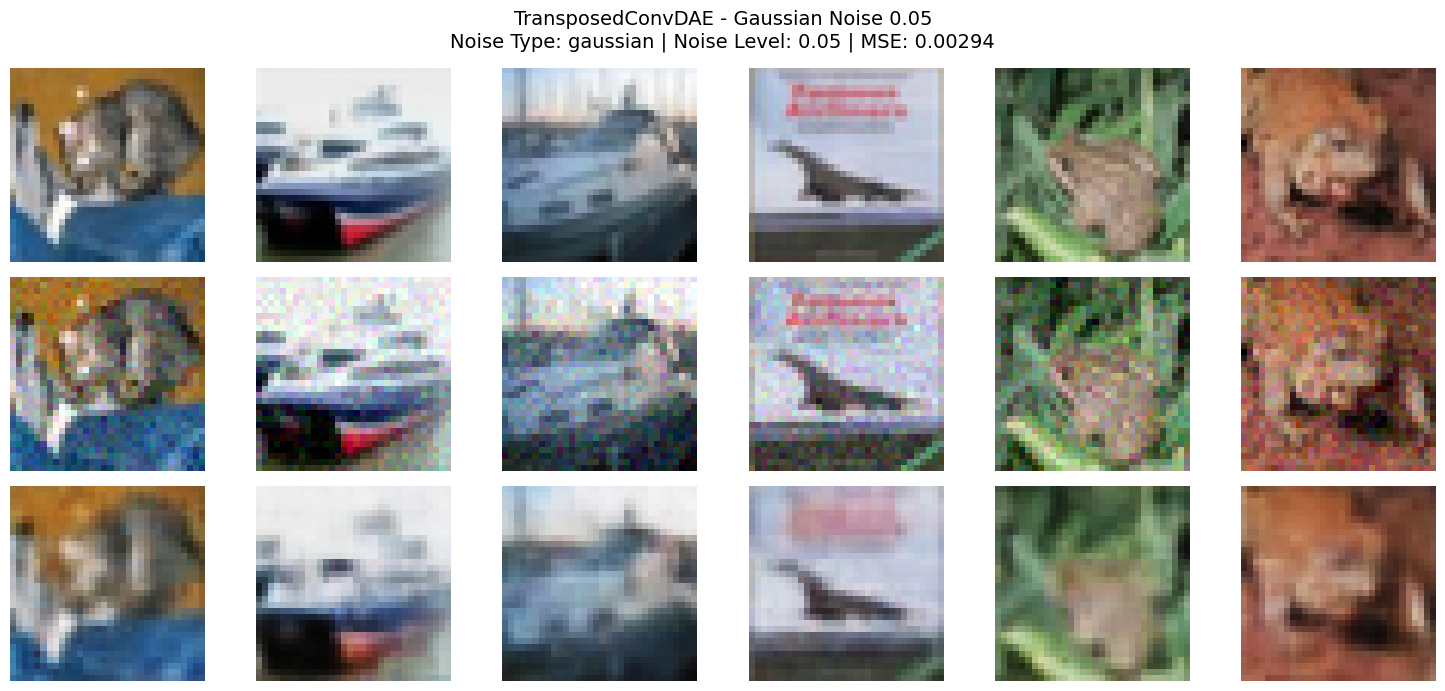


Training with Gaussian Noise Level = 0.1
Epoch [1/6] | Noise: gaussian (level=0.1) | MSE Loss: 0.012304
Epoch [2/6] | Noise: gaussian (level=0.1) | MSE Loss: 0.005522
Epoch [3/6] | Noise: gaussian (level=0.1) | MSE Loss: 0.004864
Epoch [4/6] | Noise: gaussian (level=0.1) | MSE Loss: 0.004511
Epoch [5/6] | Noise: gaussian (level=0.1) | MSE Loss: 0.004253
Epoch [6/6] | Noise: gaussian (level=0.1) | MSE Loss: 0.004042

TransposedConvDAE - Gaussian Noise 0.1 - Reconstruction MSE: 0.003945


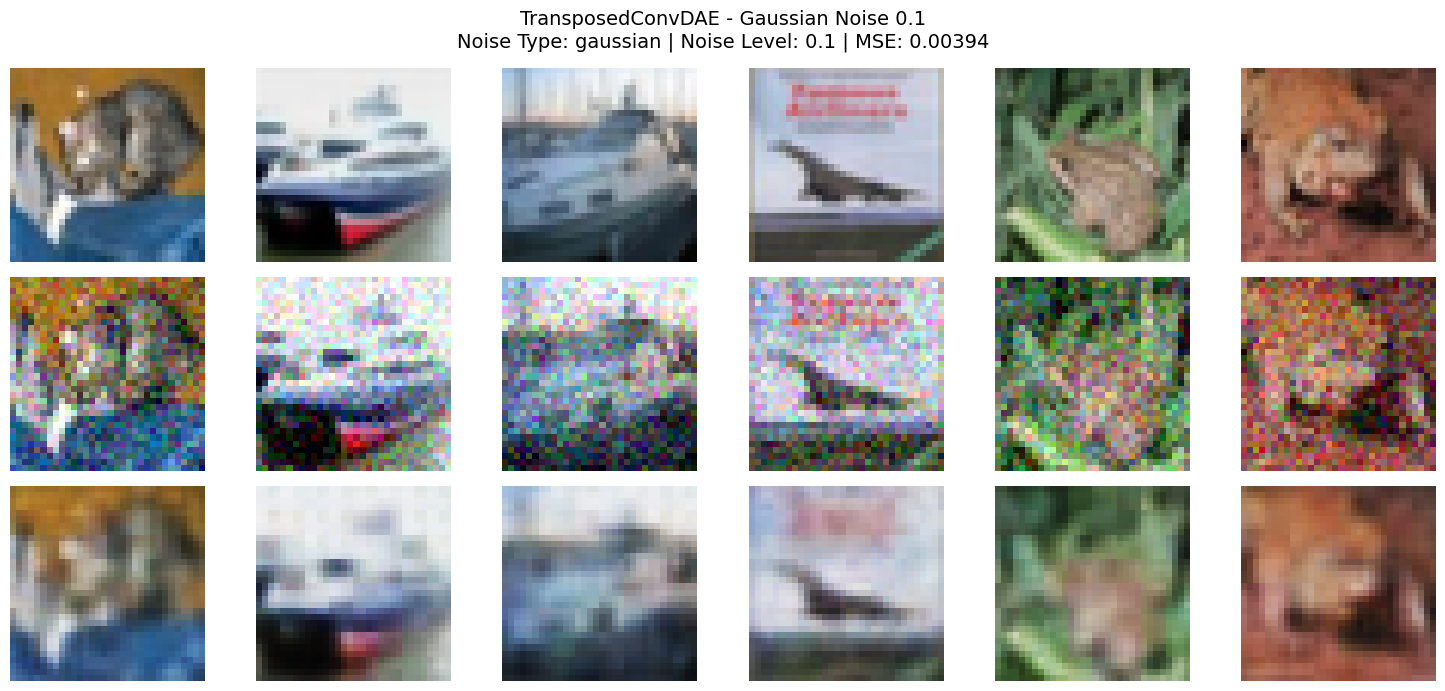


Training with Gaussian Noise Level = 0.2
Epoch [1/6] | Noise: gaussian (level=0.2) | MSE Loss: 0.012865
Epoch [2/6] | Noise: gaussian (level=0.2) | MSE Loss: 0.006893
Epoch [3/6] | Noise: gaussian (level=0.2) | MSE Loss: 0.006321
Epoch [4/6] | Noise: gaussian (level=0.2) | MSE Loss: 0.006035
Epoch [5/6] | Noise: gaussian (level=0.2) | MSE Loss: 0.005787
Epoch [6/6] | Noise: gaussian (level=0.2) | MSE Loss: 0.005613

TransposedConvDAE - Gaussian Noise 0.2 - Reconstruction MSE: 0.005513


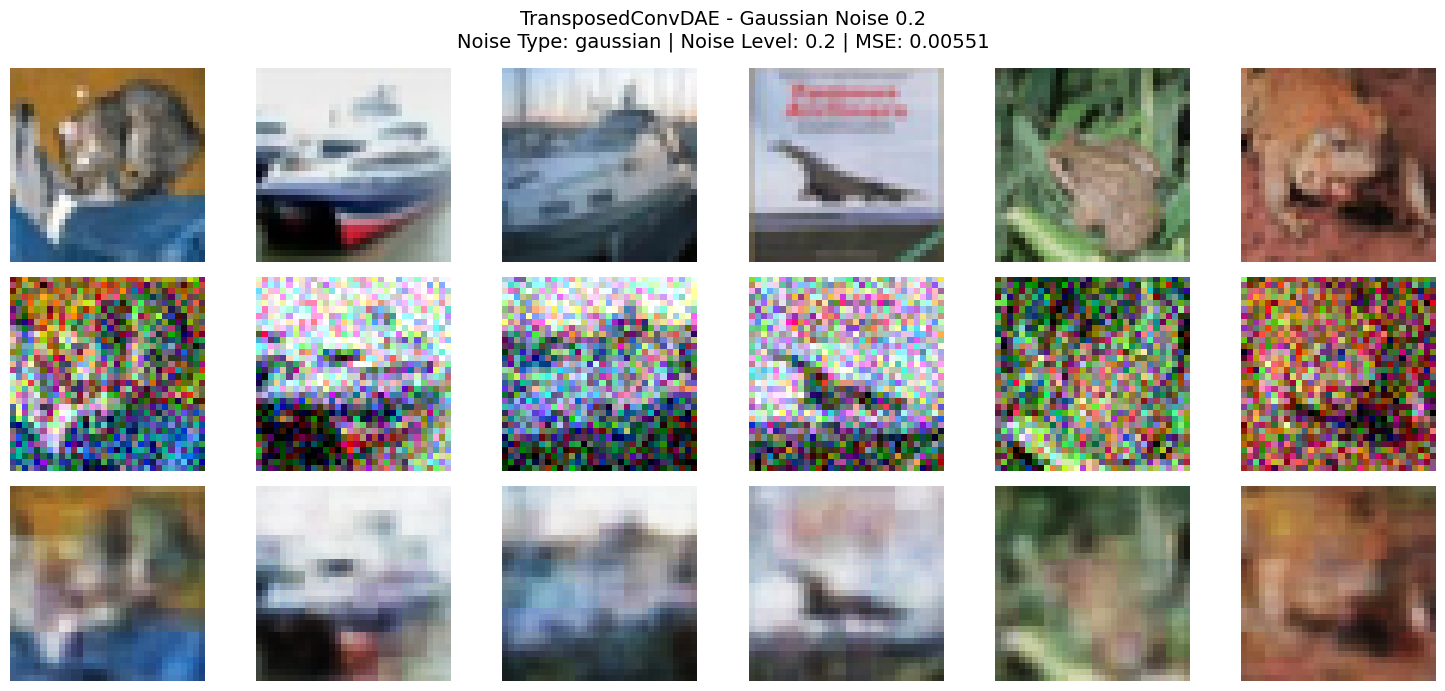

In [20]:
print("=== EXPERIMENT 1: Effect of Different Noise Levels (Gaussian) ===\n")

noise_levels = [0.05, 0.1, 0.2]
results = []

for level in noise_levels:
    print(f"\nTraining with Gaussian Noise Level = {level}")
    model = build_transposed_dae()
    train_model(model, noise_type='gaussian', noise_level=level, epochs=6)
    mse = evaluate_and_visualize(model, noise_type='gaussian', noise_level=level,
                               title=f"TransposedConvDAE - Gaussian Noise {level}")
    results.append((level, mse))

## Experiment 2: Salt-and-Pepper Noise
Evaluating the model using Salt-and-Pepper noise as required.

=== EXPERIMENT 2: Salt-and-Pepper Noise ===

Epoch [1/6] | Noise: salt_pepper (level=0.1) | MSE Loss: 0.013051
Epoch [2/6] | Noise: salt_pepper (level=0.1) | MSE Loss: 0.006602
Epoch [3/6] | Noise: salt_pepper (level=0.1) | MSE Loss: 0.005912
Epoch [4/6] | Noise: salt_pepper (level=0.1) | MSE Loss: 0.005430
Epoch [5/6] | Noise: salt_pepper (level=0.1) | MSE Loss: 0.005030
Epoch [6/6] | Noise: salt_pepper (level=0.1) | MSE Loss: 0.004692

TransposedConvDAE - Salt & Pepper Noise - Reconstruction MSE: 0.004422


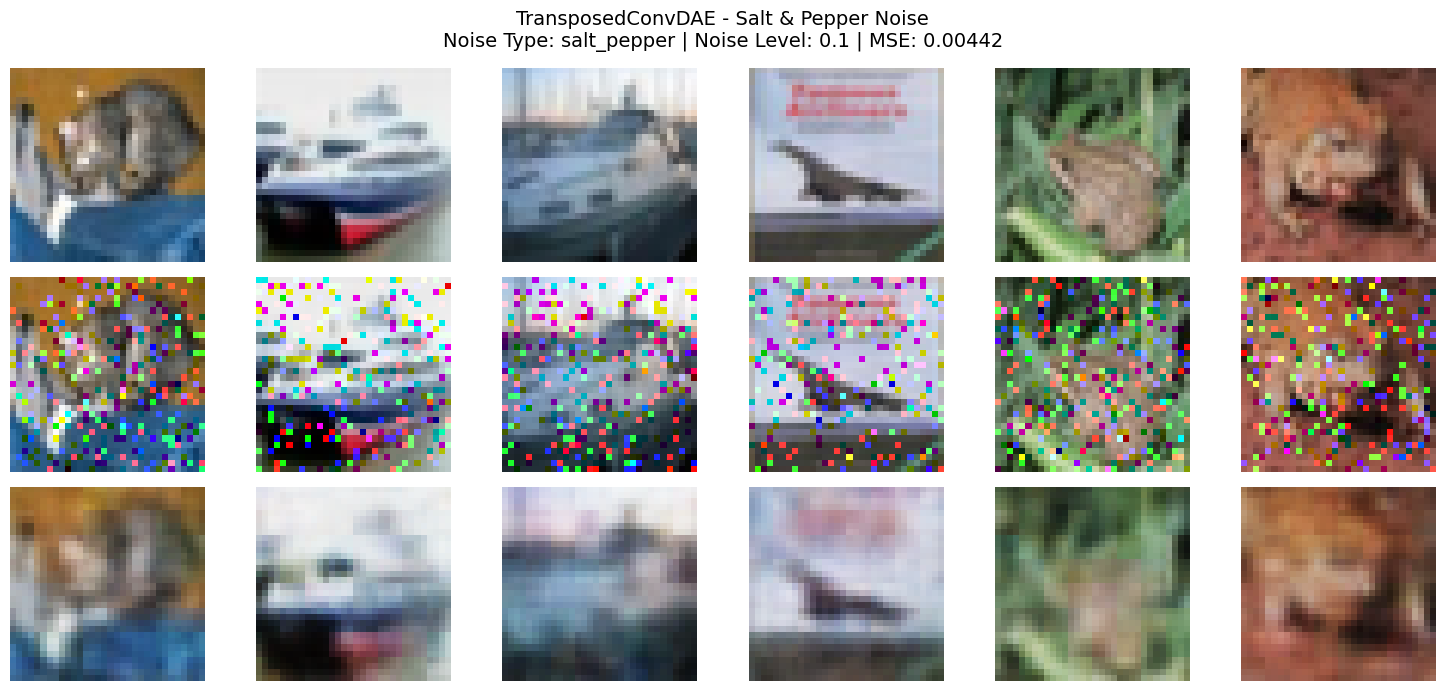

np.float32(0.004422289)

In [22]:
print("=== EXPERIMENT 2: Salt-and-Pepper Noise ===\n")
model_sp = build_transposed_dae()
train_model(model_sp, noise_type='salt_pepper', noise_level=0.1, epochs=6)
evaluate_and_visualize(model_sp, noise_type='salt_pepper', noise_level=0.1,
                      title="TransposedConvDAE - Salt & Pepper Noise")

## Experiment 3 & 4: Impact of Encoder Architecture & Upsampling Techniques
Comparing:
- Transposed Convolution vs UpSampling2D (different upsampling techniques)
- Encoder design impact (same encoder used with different decoders)

This fulfills the requirement to examine architecture choices and upsampling methods.

=== EXPERIMENT 3 & 4: Upsampling Techniques & Encoder Architecture ===

Training TransposedConvDAE...
Epoch [1/6] | Noise: gaussian (level=0.1) | MSE Loss: 0.013081
Epoch [2/6] | Noise: gaussian (level=0.1) | MSE Loss: 0.005504
Epoch [3/6] | Noise: gaussian (level=0.1) | MSE Loss: 0.004747
Epoch [4/6] | Noise: gaussian (level=0.1) | MSE Loss: 0.004329
Epoch [5/6] | Noise: gaussian (level=0.1) | MSE Loss: 0.004064
Epoch [6/6] | Noise: gaussian (level=0.1) | MSE Loss: 0.003868

Transposed Convolution DAE - Reconstruction MSE: 0.003647


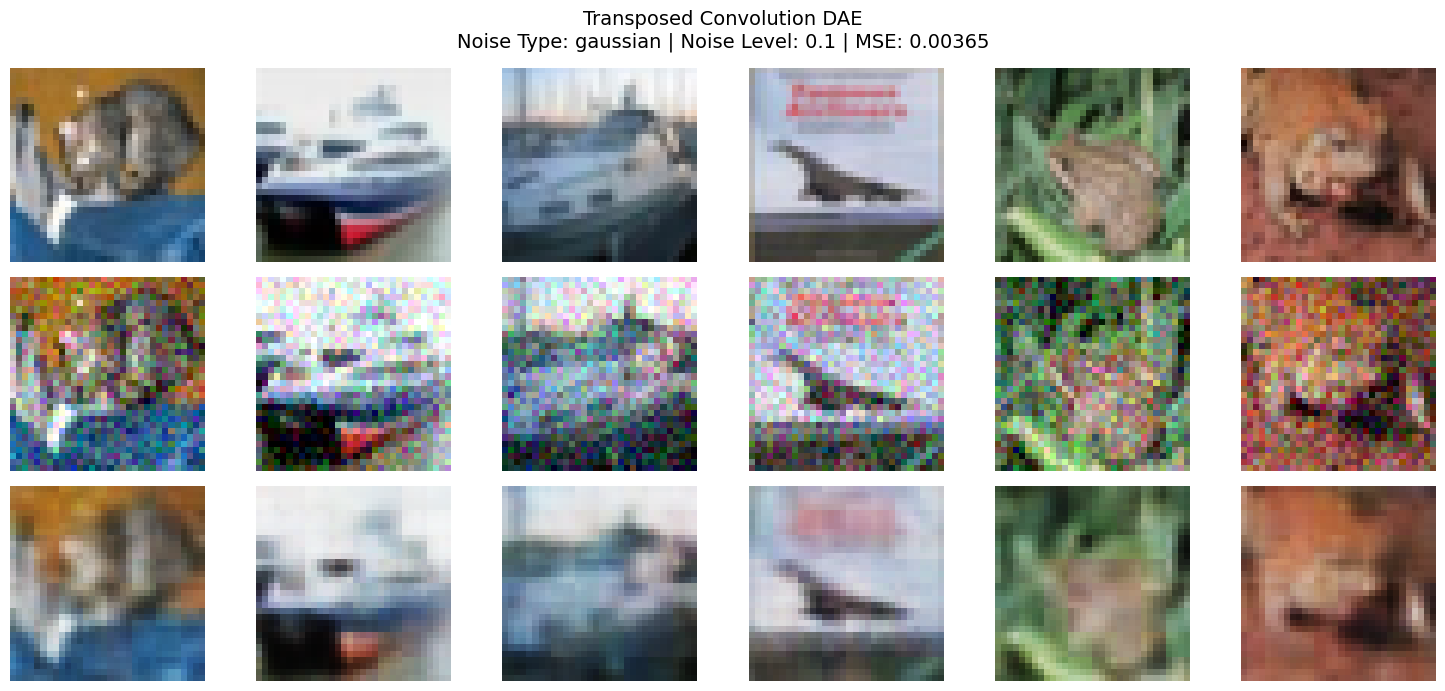


Training UpsamplingDAE...
Epoch [1/6] | Noise: gaussian (level=0.1) | MSE Loss: 0.008911
Epoch [2/6] | Noise: gaussian (level=0.1) | MSE Loss: 0.004798
Epoch [3/6] | Noise: gaussian (level=0.1) | MSE Loss: 0.004130
Epoch [4/6] | Noise: gaussian (level=0.1) | MSE Loss: 0.003724
Epoch [5/6] | Noise: gaussian (level=0.1) | MSE Loss: 0.003418
Epoch [6/6] | Noise: gaussian (level=0.1) | MSE Loss: 0.003233

UpSampling2D DAE - Reconstruction MSE: 0.003151


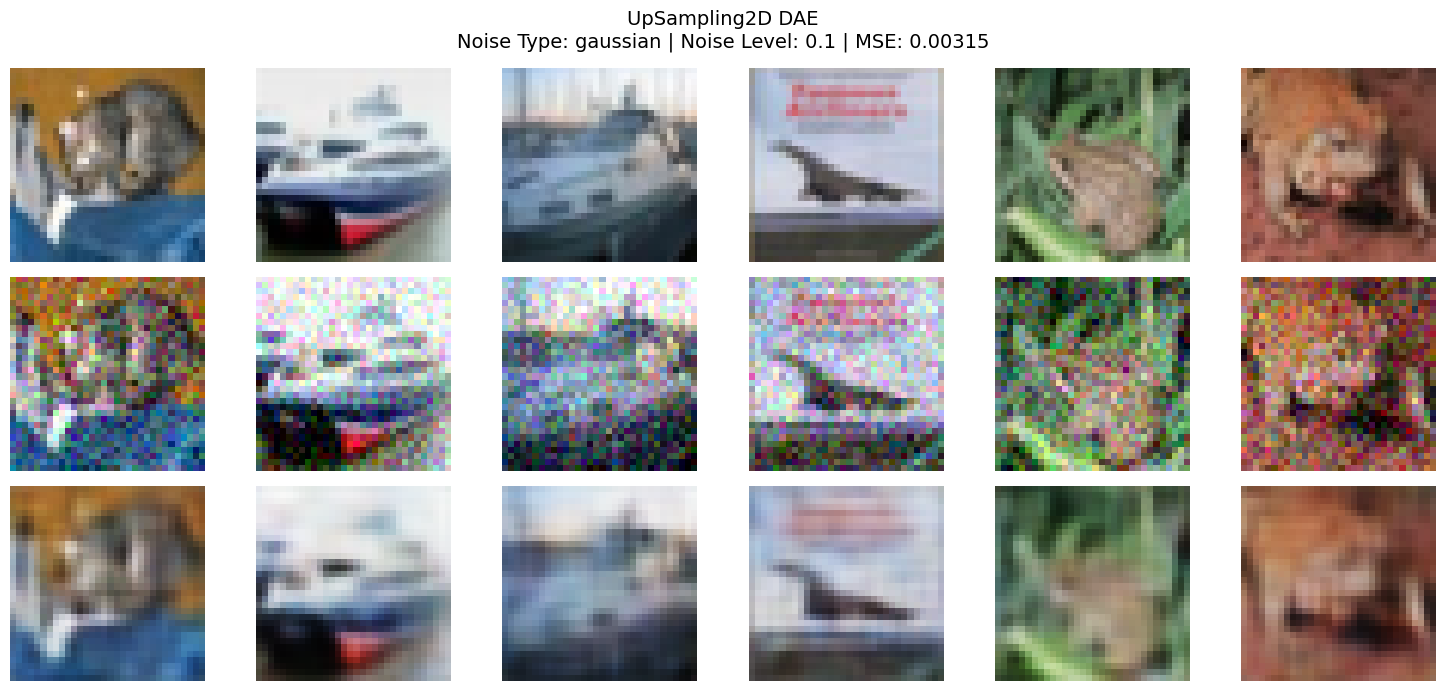

In [23]:
print("=== EXPERIMENT 3 & 4: Upsampling Techniques & Encoder Architecture ===\n")

# 1. Transposed Convolution
print("Training TransposedConvDAE...")
model_trans = build_transposed_dae()
train_model(model_trans, noise_type='gaussian', noise_level=0.1, epochs=6)
mse_trans = evaluate_and_visualize(model_trans, noise_type='gaussian', noise_level=0.1,
                                 title="Transposed Convolution DAE")

# 2. UpSampling2D (proxy for Max Unpooling style)
print("\nTraining UpsamplingDAE...")
model_up = build_upsampling_dae()
train_model(model_up, noise_type='gaussian', noise_level=0.1, epochs=6)
mse_up = evaluate_and_visualize(model_up, noise_type='gaussian', noise_level=0.1,
                              title="UpSampling2D DAE")

## Proposal to Address Limited Annotated Ground Truth Data

1. **Synthetic Noise Injection**: Generate noisy versions of large unlabeled image collections to create pseudo-paired data for training without needing clean annotated ground truth.
2. **Self-Supervised Learning**: Train using different noise realizations of the same image as input and target.
3. **Pre-training on Unlabeled Data**: Pre-train on massive unlabeled datasets (e.g. unlabeled ImageNet or web images) with synthetic noise, then fine-tune.
4. **Consistency Regularization & Data Augmentation**: Enforce consistency between differently noised versions of same images.
5. **Generative Approaches**: Use Denoising Diffusion models or GAN-based methods that learn the noise distribution without paired clean-noisy labeled data.

These methods greatly reduce dependency on expensive annotated ground truth.